In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


# Importing Libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
data=pd.read_csv('../input/pima-indians-diabetes-database/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 1. Basic Data Exploration and Cleaning up

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#**Check missing(zero) values**

In [5]:
print('total rows in dataset: {0}'.format(len(data)))
print('total rows in Pregnancies: {0}'.format(sum(data['Pregnancies']==0)))
print('total rows in Glucose: {0}'.format(sum(data['Glucose']==0)))
print('total rows in BloodPressure: {0}'.format(sum(data['BloodPressure']==0)))
print('total rows in SkinThickness: {0}'.format(sum(data['SkinThickness']==0)))
print('total rows in Insulin: {0}'.format(sum(data['Insulin']==0)))
print('total rows in BMI: {0}'.format(sum(data['BMI']==0)))
print('total rows in DiabetesPedigreeFunction: {0}'.format(sum(data['DiabetesPedigreeFunction']==0)))
print('total rows in Age: {0}'.format(sum(data['Age']==0)))

total rows in dataset: 768
total rows in Pregnancies: 111
total rows in Glucose: 5
total rows in BloodPressure: 35
total rows in SkinThickness: 227
total rows in Insulin: 374
total rows in BMI: 11
total rows in DiabetesPedigreeFunction: 0
total rows in Age: 0


#**Viewing more details about the data**

In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#**Check correlation between columns to decide the strategy for dealing with zero values**

In [7]:
data_correl=data.corr()
data_correl

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<AxesSubplot:>

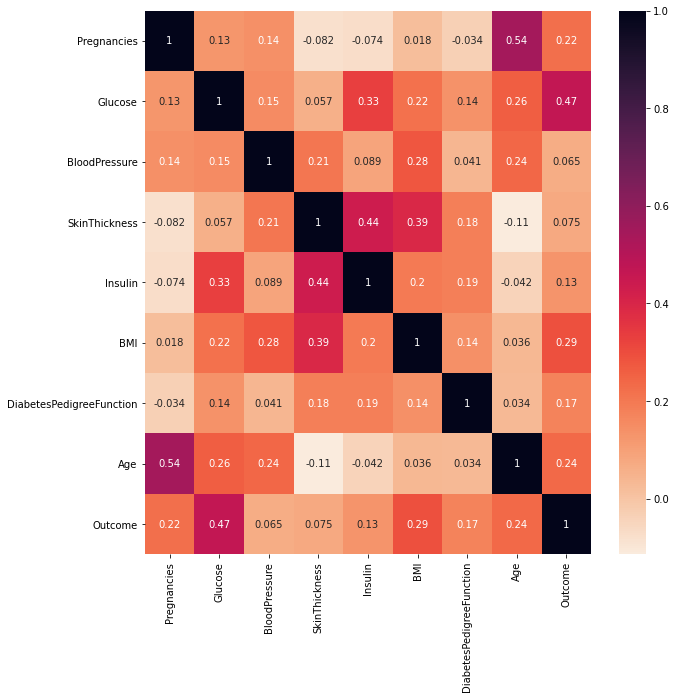

In [8]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),annot=True,cmap='rocket_r')

#**Replace zero values with mean**

In [9]:
features=data.columns[1:-3]
features

Index(['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'], dtype='object')

In [10]:
data[features]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148,72,35,0,33.6
1,85,66,29,0,26.6
2,183,64,0,0,23.3
3,89,66,23,94,28.1
4,137,40,35,168,43.1
...,...,...,...,...,...
763,101,76,48,180,32.9
764,122,70,27,0,36.8
765,121,72,23,112,26.2
766,126,60,0,0,30.1


In [11]:
data[features]=data[features].replace(0,np.nan)

In [12]:
data.fillna(data[features].mean(), inplace = True)

In [13]:
data[features]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148.0,72.0,35.00000,155.548223,33.6
1,85.0,66.0,29.00000,155.548223,26.6
2,183.0,64.0,29.15342,155.548223,23.3
3,89.0,66.0,23.00000,94.000000,28.1
4,137.0,40.0,35.00000,168.000000,43.1
...,...,...,...,...,...
763,101.0,76.0,48.00000,180.000000,32.9
764,122.0,70.0,27.00000,155.548223,36.8
765,121.0,72.0,23.00000,112.000000,26.2
766,126.0,60.0,29.15342,155.548223,30.1


#Recheck Correlation

<AxesSubplot:>

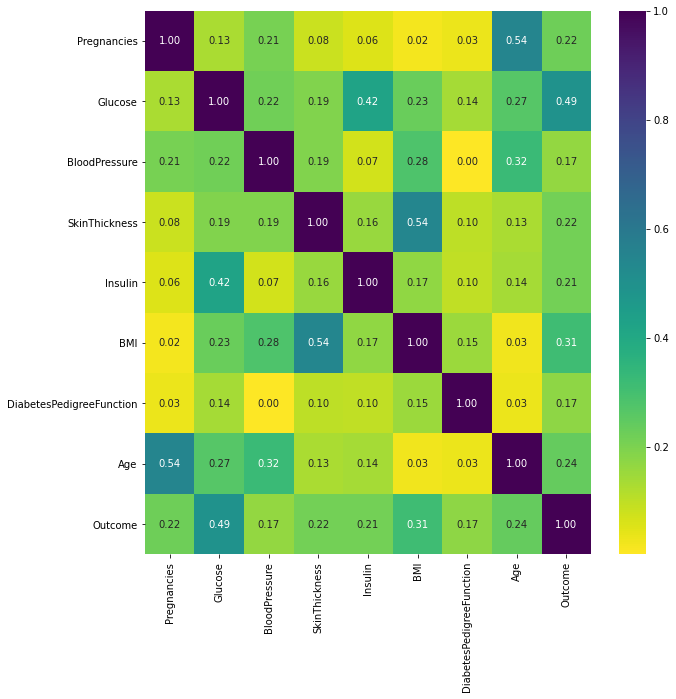

In [14]:
plt.figure(figsize=(10,10))
sns.heatmap(np.abs(data.corr()),annot=True,cmap='viridis_r',fmt="0.2f")

#**Check the mean of independent variables based on their category**

In [15]:
data.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.710121,70.935397,27.768651,142.210761,30.888434,0.429734,31.190000
1,4.865672,142.165573,75.147324,31.736944,180.431548,35.384757,0.550500,37.067164


#People with diabetes seems to have relatively more number of pregnancies, higher Skin Thickness and BMI

#Modelling